In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)

In [3]:
def generate_data(centers, std_dev, n_points_each=20, outliers_to_add=[]):
    n_dim = len(centers[0])

    classes = [np.random.normal(loc=np.array(centers[i]), scale=std_dev, size=(n_points_each, n_dim)) for i in range(len(centers))]

    for point in outliers_to_add:
        classes.append(np.array([point]))

    # Plot the data
    plt.figure()
    for i in classes:
        plt.scatter(i[:, 0], i[:, 1])

    # Create a DataFrame with a column for the x values, a column for the y values, and a column for the class
    df = pd.DataFrame(np.concatenate(classes), columns=['x', 'y'])
    df['class'] = np.concatenate([[i]*n_points_each for i in range(len(centers))] + [[-1]*len(outliers_to_add)])

    # shuffle
    df = df.sample(frac=1).reset_index(drop=True)
    
    return df

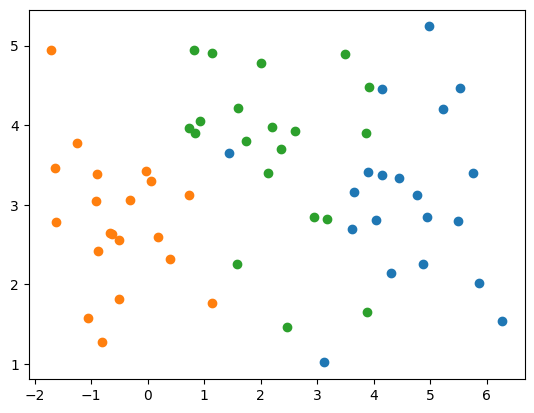

In [4]:
df = generate_data([[4, 3], [0, 3], [2, 3]], 1.0)

In [5]:
df.loc[df['x'] < 1, 'class'] = 1.0
df.loc[df['x'] > 1, 'class'] = 2.0
df.loc[df['x'] > 3, 'class'] = 0.0

In [6]:
# order by x
df.sort_values(by='x')

,x,y,class
25,-1.706270,4.950775,1.0
6,-1.630198,3.462782,1.0
20,-1.613898,2.787260,1.0
44,-1.252795,3.777490,1.0
56,-1.048553,1.579982,1.0
5,-0.907298,3.051945,1.0
45,-0.895467,3.386902,1.0
37,-0.870797,2.421150,1.0
32,-0.813146,1.273717,1.0
0,-0.672460,2.640447,1.0


In [7]:
#iloc
#df.iloc[8]['class'] = 0.0
df.iloc[3]['class'] = 1.0
df.iloc[2]['class'] = 1.0

/var/folders/qn/sypqqw3101v1k6_70wqyd99h0000gn/T/ipykernel_23533/2709532490.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.iloc[3]['class'] = 1.0
/var/folders/qn/sypqqw3101v1k6_70wqyd99h0000gn/T/ipykernel_23533/2709532490.py:4: Futur

/var/folders/qn/sypqqw3101v1k6_70wqyd99h0000gn/T/ipykernel_23533/2578798984.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_accents = plt.cm.get_cmap('Accent')


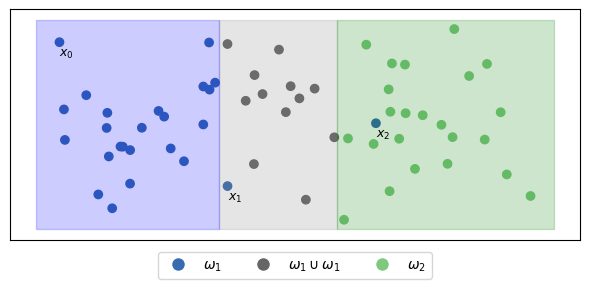

In [8]:
cmap_accents = plt.cm.get_cmap('Accent')

# Plot the data
plt.figure(figsize=(6, 3))
plt.scatter(df['x'], df['y'], c=df['class'], cmap='Accent')
# get limits
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
# paint regions > 3 and < 1
plt.fill_between([1, 3], y_min, y_max, color='gray', alpha=0.2)
plt.fill_between([3, x_max], y_min, y_max, color='green', alpha=0.2)
plt.fill_between([x_min, 1], y_min, y_max, color='blue', alpha=0.2)
# remove ticks
plt.xticks([])
plt.yticks([])
# Write the $x_1$ and $x_2$ at ilocs 2 and 3
plt.text(df.iloc[2]['x'], df.iloc[2]['y'] - 0.3, '$x_2$', fontsize=9, color='black')
plt.text(df.iloc[3]['x'], df.iloc[3]['y'] - 0.3, '$x_1$', fontsize=9, color='black')
plt.text(df.iloc[25]['x'], df.iloc[25]['y'] - 0.3, '$x_0$', fontsize=9, color='black')

# add legend externally
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='$\omega_1$', markerfacecolor=cmap_accents(4), markersize=10),
                    plt.Line2D([0], [0], marker='o', color='w', label='$\omega_1 \cup \omega_1$', markerfacecolor=cmap_accents(8), markersize=10),
                    plt.Line2D([0], [0], marker='o', color='w', label='$\omega_2$', markerfacecolor=cmap_accents(0), markersize=10)],
                    loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.2))

# tight layout
plt.tight_layout()
# export
plt.savefig('similarity_figure.pdf', bbox_inches='tight')
plt.show()

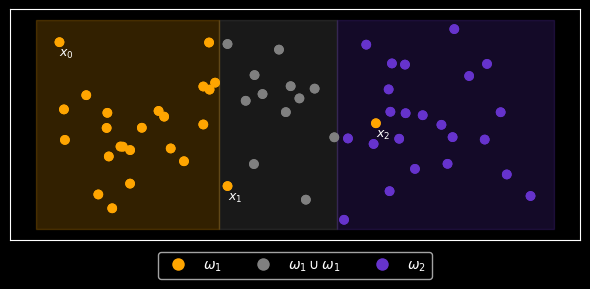

In [66]:
from matplotlib.colors import ListedColormap
plt.style.use('dark_background')

# create cmap
cmap_new = ListedColormap([(0.4, 0.2, 0.8, 1),
                           'orange', 
                           'gray'])

# Plot the data
plt.figure(figsize=(6, 3))
plt.scatter(df['x'], df['y'], c=df['class'], cmap=cmap_new)
# get limits
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
# paint regions > 3 and < 1
plt.fill_between([1, 3], y_min, y_max, color=cmap_new(2), alpha=0.2)
plt.fill_between([3, x_max], y_min, y_max, color=cmap_new(0), alpha=0.2)
plt.fill_between([x_min, 1], y_min, y_max, color=cmap_new(1), alpha=0.2)
plt.scatter(df['x'], df['y'], c=df['class'], cmap=cmap_new)
# remove ticks
plt.xticks([])
plt.yticks([])
# Write the $x_1$ and $x_2$ at ilocs 2 and 3
plt.text(df.iloc[2]['x'], df.iloc[2]['y'] - 0.3, '$x_2$', fontsize=9, color='w')
plt.text(df.iloc[3]['x'], df.iloc[3]['y'] - 0.3, '$x_1$', fontsize=9, color='w')
plt.text(df.iloc[25]['x'], df.iloc[25]['y'] - 0.3, '$x_0$', fontsize=9, color='w')

# add legend externally
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='black', label='$\omega_1$', markerfacecolor=cmap_new(1), markersize=10),
                    plt.Line2D([0], [0], marker='o', color='black', label='$\omega_1 \cup \omega_1$', markerfacecolor=cmap_new(2), markersize=10),
                    plt.Line2D([0], [0], marker='o', color='black', label='$\omega_2$', markerfacecolor=cmap_new(0), markersize=10)],
                    loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.2))

# tight layout
plt.tight_layout()
# export
plt.savefig('similarity_figure_dark.pdf', bbox_inches='tight')
plt.show()